<a href="https://colab.research.google.com/github/prasa129/Econometrics/blob/main/EM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Expectation Maximization - Bimodal GMM

10-22-2025

Implementation of expectation maximization algorithm for bimodal 1D GMM. Simulate data, explicit treatment of algorithm, compare algorithm's estimates to simulation parameters (ground truth values).

##1. Generate Data

I simulate 1000 samples from the bimodal one dimensional GMM:

\begin{align*}
p(x;\theta) &= w \cdot \mathcal{N}(\mu_{1}, \sigma^{2}_{1}) + (1-w)\cdot N(\mu_{2}, \sigma^{2}_{2}) \\
\theta &=(w, \mu_{1}, \mu_{2}, \sigma_{1}, \sigma_{2})
\end{align*}

where $w=1/3, \mu_{1}=1, \mu_{2}=3, \sigma_{1}=1, \sigma_{2}=2$.

Model moments are:

\begin{align*}
E_{p}(x) &= w\mu_{1} + (1-w)\mu_{2} = \frac{1 + 2\cdot3}{3} = \frac{7}{3} \\
E_{p}(x^{2}) &= w(\sigma_{1}^{2} + \mu_{1}^{2}) + (1-w)(\sigma_{2}^{2} + \mu_{2}^{2}) = \frac{2}{3} + \frac{26}{3} = \frac{28}{3} \\
\text{Var}_{p}(x) &= E_{p}(x^{2}) - E_{p}^{2}(x) = \frac{28}{3} - \frac{49}{9} = \frac{35}{9}
\end{align*}

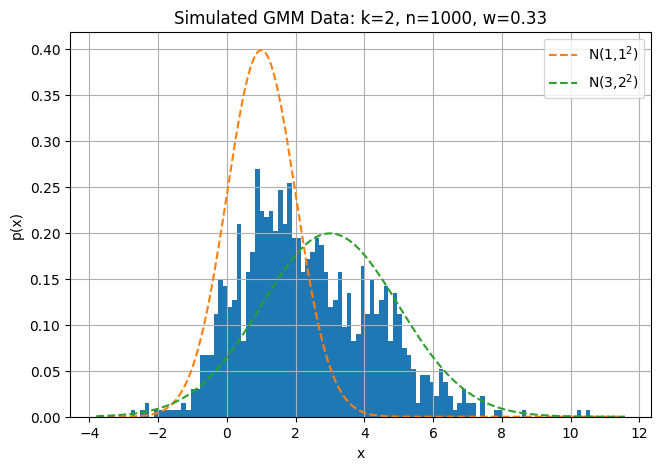

Sample mean: 2.34
Sample variance: 3.72


In [1]:
# standard imports
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import bernoulli
from scipy.stats import norm

# set seed for reproducability
np.random.seed(1337)

# set simulation parameters
n = 1000
w = 1/3
mu_1,  mu_2 = 1, 3
sigma_1, sigma_2 = 1, 2

# vectorize
theta = np.array([w, mu_1, mu_2, sigma_1, sigma_2])


# normal density
def normal_pdf(x, mu, sigma):
    """
    Vectorized normal density.
    Args:
      x, np.array: data
      mu, float: mean
      sigma, float: standard deviation
    Returns:
      f, np.array: array of normal densities
    """
    # evaluate density
    f = 1/(np.sqrt(2*np.pi*sigma**2))*np.exp((-(x - mu)**2)/(2*sigma**2))
    return f


# simulate
def sim_gmm(theta, n):
    """
    Simulate data from Gaussian mixture model.
    Args:
      theta, np.array: vector of parameters
      n, int: number of samples
    Returns:
      x, np.array: array of samples
    Sample from 2 density mixture using Bern(w)
    draws.
    """
    # unpack parameters
    w, mu_1, mu_2, sigma_1, sigma_2 = theta

    # Bernoulli draws - note sp's uses 1 w/prob p, 0 w/prob 1-p
    z = bernoulli.rvs(1-w, size=n)

    # init vector for draws
    x = np.empty(n)

    # populate vectors with draws from density 1
    x[z == 0] = np.random.normal(mu_1, sigma_1, np.sum(z == 0))

    # populate vector with draws from density 2
    x[z == 1] = np.random.normal(mu_2, sigma_2, np.sum(z == 1))

    # mixture density
    return x

# simulate, capture draws
sim_data = sim_gmm(theta, n)

# check data
plt.figure(figsize=(7.5,5))
plt.hist(sim_data, bins=100, density=True)

# overlay theoretical densitites
x = np.linspace(min(sim_data)-1, max(sim_data)+1, 1000)
plt.plot(x, normal_pdf(x, mu_1, sigma_1),label=f'N({mu_1},{sigma_1}'+r'$^{2}$)',
         linestyle="--")
plt.plot(x, normal_pdf(x, mu_2, sigma_2),label=f'N({mu_2},{sigma_2}'+r'$^{2}$)',
         linestyle="--")

# label, title, legend
plt.xlabel('x')
plt.ylabel('p(x)')
plt.title(f'Simulated GMM Data: k=2, n={n}, w={np.round(w,2)}')
plt.legend()
plt.grid()
plt.show()

# check sample moments
print(f'Sample mean: {np.round(np.mean(sim_data),2)}')
print(f'Sample variance: {np.round(np.var(sim_data, ddof=1),2)}')

Sample moments (2.34, 3.72) of simulated data are close to model's theoretical moments (2.33, 3.88). The histogram is reasonable for a bimodal GMM.


##2. EM for a 2-Component Univariate Gaussian Mixture

#### Model and Notation

Given data $ x_1,\dots,x_n \in \mathbb{R} $, parameters
$$
\theta = (w, \mu_1, \mu_2, \sigma_1, \sigma_2), \qquad
w \in (0,1),\ \mu_k \in \mathbb{R},\ \sigma_k > 0,
$$

the mixture density is

$$
p(x_i \mid \theta) = w\,\mathcal{N}(x_i \mid \mu_1,\sigma_1^2)
+ (1-w)\,\mathcal{N}(x_i \mid \mu_2,\sigma_2^2),
$$

with the univariate Gaussian pdf

$$
\mathcal{N}(x \mid \mu,\sigma^2) =
\frac{1}{\sqrt{2\pi}\,\sigma}\exp\!\left(-\frac{(x-\mu)^2}{2\sigma^2}\right).
$$

#### Initialization
Given an initial guess

$$
\theta^{(0)} = \bigl(w^{(0)}, \mu_1^{(0)}, \mu_2^{(0)}, \sigma_1^{(0)}, \sigma_2^{(0)}\bigr),
$$

set $\ell^{(0)} = -\infty$ and $t=0$.

#### E-step
For $k \in \{0,1\}$ define

$$
w_0^{(t)} = w^{(t)}, \qquad w_1^{(t)} = 1 - w^{(t)}.
$$

For each $i=1,\dots,n$, compute responsibilities (with numerical stabilizer $\varepsilon > 0$)

$$
r_{ik}^{(t)} =
\frac{w_k^{(t)} \, \mathcal{N}\!\bigl(x_i \mid \mu_{k+1}^{(t)}, (\sigma_{k+1}^{(t)})^2\bigr)}
{w^{(t)} \, \mathcal{N}\!\bigl(x_i \mid \mu_1^{(t)}, (\sigma_1^{(t)})^2\bigr)
 + (1-w^{(t)}) \, \mathcal{N}\!\bigl(x_i \mid \mu_2^{(t)}, (\sigma_2^{(t)})^2\bigr)
 + \varepsilon}.
$$

In particular,

$$
r_{i0}^{(t)} =
\frac{w^{(t)} \, \mathcal{N}\!\bigl(x_i \mid \mu_1^{(t)}, (\sigma_1^{(t)})^2\bigr)}
{w^{(t)} \, \mathcal{N}\!\bigl(x_i \mid \mu_1^{(t)}, (\sigma_1^{(t)})^2\bigr)
 + (1-w^{(t)}) \, \mathcal{N}\!\bigl(x_i \mid \mu_2^{(t)}, (\sigma_2^{(t)})^2\bigr)
 + \varepsilon}, \qquad
r_{i1}^{(t)} = 1 - r_{i0}^{(t)}.
$$

#### M-step.
Let

$$
N_0^{(t)} = \sum_{i=1}^n r_{i0}^{(t)}, \qquad
N_1^{(t)} = \sum_{i=1}^n r_{i1}^{(t)}.
$$

Update:

$$
\mu_1^{(t+1)} = \frac{\sum_{i=1}^n r_{i0}^{(t)}\,x_i}{N_0^{(t)}},
\qquad
\mu_2^{(t+1)} = \frac{\sum_{i=1}^n r_{i1}^{(t)}\,x_i}{N_1^{(t)}},
$$

$$
\sigma_1^{(t+1)} = \sqrt{\frac{\sum_{i=1}^n r_{i0}^{(t)}\,(x_i-\mu_1^{(t+1)})^2}{N_0^{(t)}}},
\qquad
\sigma_2^{(t+1)} = \sqrt{\frac{\sum_{i=1}^n r_{i1}^{(t)}\,(x_i-\mu_2^{(t+1)})^2}{N_1^{(t)}}}.
$$

Clip to enforce positivity and interior weights:

$$
\sigma_k^{(t+1)} \leftarrow \max\bigl(\sigma_k^{(t+1)}, \varepsilon\bigr), \quad k=1,2,
\qquad
w^{(t+1)} = \frac{N_0^{(t)}}{n}, \quad
w^{(t+1)} \leftarrow \min\bigl(\max(w^{(t+1)},\varepsilon), 1-\varepsilon\bigr).
$$

#### Log-likelihood

Compute the observed-data log-likelihood

$$
\ell^{(t+1)} = \sum_{i=1}^n \log\!\Bigl(
w^{(t+1)} \, \mathcal{N}\!\bigl(x_i \mid \mu_1^{(t+1)}, (\sigma_1^{(t+1)})^2\bigr)
+ (1 - w^{(t+1)}) \, \mathcal{N}\!\bigl(x_i \mid \mu_2^{(t+1)}, (\sigma_2^{(t+1)})^2\bigr)
+ \varepsilon
\Bigr).
$$

#### Convergence criteria
Let the parameter vector at iteration $t$ be

$$
\theta^{(t)} = \bigl(w^{(t)}, \mu_1^{(t)}, \mu_2^{(t)}, \sigma_1^{(t)}, \sigma_2^{(t)}\bigr).
$$

Define the (Euclidean) $ \ell_2 $ norm for a vector $v \in \mathbb{R}^d$ by

$$
\|v\|_2 \triangleq \sqrt{\sum_{j=1}^d v_j^2}.
$$

Define the relative parameter tolerance:

$$
\text{rel}_{\text{tol}}^{(t)} = \theta_{\text{tol}} \bigl(1 + \|\theta^{(t)}\|_2 \bigr).
$$

Stop the iterations if any of the following holds:

$$
\bigl| \ell^{(t+1)} - \ell^{(t)} \bigr| < \text{ll}_{\text{tol}},
\qquad
\|\theta^{(t+1)} - \theta^{(t)}\|_2 < \text{rel}_{\text{tol}}^{(t)},
\qquad
t \ge \text{max}_{\text{iter}}.
$$

If the first two fail but the last triggers, print a warning for maximum iterations. If neither tolerance is met, print parameter convergence failure warning.

#### Output

At termination (iteration $T$), return

$$
\hat{\theta} = \theta^{(T)}, \qquad
\ell_{\text{hist}} = \bigl[\ell^{(1)}, \dots, \ell^{(T)}\bigr], \qquad
T.
$$

#### Post-processing (label identification)
After EM, reorder so that $\mu_1 < \mu_2$:

$$
\text{if } \mu_1 > \mu_2:\quad
w' = 1 - w,\quad
\mu_1' = \mu_2,\ \mu_2' = \mu_1,\quad
\sigma_1' = \sigma_2,\ \sigma_2' = \sigma_1,
$$

and set $\theta' = (w', \mu_1', \mu_2', \sigma_1', \sigma_2')$.

#### Refitting (Multi-start Search)

To mitigate local maxima and label switching, we perform $N_{\text{fits}}$ random restarts with different initializations.

1. **Compute summary stats**

   Compute the sample standard deviation and percentiles:
   $$
   \hat{s} = \sqrt{\frac{1}{n-1}\sum_{i=1}^n (x_i - \bar{x})^2}, \qquad
   q_{25},\; q_{75}.
   $$

2. **Baseline initialization**

   Set the baseline parameter vector:
   $$
   \theta_0 = (0.5,\; q_{25},\; q_{75},\; \hat{s},\; \hat{s}).
   $$

3. **Baseline EM fit**

   Run EM once to obtain:
   $$
   \bigl(\theta^{(0)},\; \ell^{(0)},\; T^{(0)}\bigr).
   $$

4. **Random restarts ($j=1,\dots, N_{\text{fits}}$)**

   a) Draw two random starting means from the data:
   $$
   \mu_{1}^{(0,j)},\; \mu_{2}^{(0,j)} \sim \text{UniformSample}\bigl(\{x_i\}_{i=1}^n\bigr).
   $$

   b) Form the $j$-th initial parameter vector:
   $$
   \theta^{(0,j)} = \bigl(0.5,\; \mu_{1}^{(0,j)},\; \mu_{2}^{(0,j)},\; \hat{s},\; \hat{s}\bigr).
   $$

   c) Run EM with this initialization to get:
   $$
   \bigl(\theta^{(j)},\; \ell^{(j)},\; T^{(j)}\bigr) = \mathrm{EM}\!\left(\theta^{(0,j)},\; x_{1:n}\right).
   $$

   d) Keep the best log-likelihood seen so far:
   $$
   \text{if } \ell^{(j)} > \ell^{(\text{best})}:\quad
   \theta^{(\text{best})} \leftarrow \theta^{(j)}, \qquad
   \ell^{(\text{best})} \leftarrow \ell^{(j)}.
   $$

5. **Final selection**

   Choose the best parameters across all runs:
   $$
   \hat{\theta}_{\text{final}} = \theta^{(\text{best})},
   $$
   with corresponding log-likelihood and iteration count:
   $$
   \ell^{(\text{best})}, \qquad T^{(\text{best})}.
   $$

#### Label ordering for identifiability

Enforce $\mu_1 < \mu_2$ after selection:
$$
\text{if } \mu_1 > \mu_2:\quad
w' = 1 - w,\quad
\mu_1' = \mu_2,\ \mu_2' = \mu_1,\quad
\sigma_1' = \sigma_2,\ \sigma_2' = \sigma_1,
$$
and set
$$
\theta' = (w',\ \mu_1',\ \mu_2',\ \sigma_1',\ \sigma_2').
$$

---

#### Output Summary

The final output is:

$$
\bigl(\hat{\theta}_{\text{final}},\, \ell_{\text{hist}}^{(\text{best})},\, T^{(\text{best})}\bigr),
$$

where $\hat{\theta}_{\text{final}}$ is the best-fitting, label-ordered estimate among all refits.



In [2]:
def em_gmm(theta_0, data, max_iter=100, ll_tol=1e-6, theta_tol=1e-3, eps=1e-12):
    """
    EM algorithm for Gaussian mixture model.
    Args:
      theta_0, np.array: initial guess for params
      data, np.array: data
      max_iter, int: maximum number of iterations
      ll_tol, float: tolerance for log likelihood convergence
      theta_tol, float: tolerance for relative parameter estimate convergence
      eps, float: small number for numerical stability
    Returns:
      theta_hat, np.array: array of parameters
      ll_hist, np.array: array of log likelihoods
    E-step: compute posterior of z given observation and parameters
    M-step: update parameters given posterior and observations
    Use L2 norm for relative parameter estimate convergence.
    """

    # compute responsibilities
    def compute_rk(data, k, theta, eps=eps):
        """
        Compute responsibilities for Gaussian mixture model.
        Args:
          data, np.array: data
          k, int: mode index
          theta, np.array: array of parameters
          eps, float: small number for numerical stability
        Returns:
          np.array: array of responsibilities
        Add eps to denominator to avoid division by zero.
        """
        # check k is valid
        if k not in [0, 1]:
            raise ValueError('k must be 0 or 1')

        # unpack params
        w, mu_1, mu_2, sigma_1, sigma_2 = theta

        # x is nx1 data vector
        x = data

        # dict for w_k, mu_k, sigma_k
        w_k = {0: w, 1: 1-w}
        mu_k = {0: mu_1, 1: mu_2}
        sigma_k = {0: sigma_1, 1: sigma_2}

        # denominator is w*N(x_i;mu_1,sigma_1) and (1-w)*N(x_i;mu_2,sigma_2)
        denom = w*normal_pdf(x, mu_1, sigma_1)
        denom += (1-w)*normal_pdf(x, mu_2, sigma_2)

        # numerator
        num = w_k[k]*normal_pdf(x, mu_k[k], sigma_k[k])

        # return vectorized responsibilities
        return num/(denom + eps)

    # set boolean stopping conditions
    exceed_max_iter = False
    theta_converged = False
    ll_converged = False

    # initialize EM loop theta and log likelihood
    theta, theta_prev = theta_0, theta_0
    ll_hist, ll_prev = [], -np.inf
    iter = 0

    # iterate until stopping condition is true
    while not (exceed_max_iter or theta_converged or ll_converged):

        # E-step: compute posterior of z given observation and parameters
        r_0 = compute_rk(data, 0, theta)
        r_1 = compute_rk(data, 1, theta)

        # M-step: update mean parameters
        mu_1_new = np.sum(r_0*data)/np.sum(r_0)
        mu_2_new = np.sum(r_1*data)/np.sum(r_1)

        # update variance parameters
        sigma_1_new = np.sqrt(np.sum(r_0*(data - mu_1_new)**2)/np.sum(r_0))
        sigma_2_new = np.sqrt(np.sum(r_1*(data - mu_2_new)**2)/np.sum(r_1))

        # update weights
        w_new = np.sum(r_0)/len(data)

        # ensure weight bounded, std. dev. strictly positive
        w_new = np.clip(w_new, eps, 1-eps)
        sigma_1_new = np.clip(sigma_1_new, eps, None)
        sigma_2_new = np.clip(sigma_2_new, eps, None)

        # update theta vector
        theta = np.array([w_new, mu_1_new, mu_2_new, sigma_1_new, sigma_2_new])

        # compute LL
        ll = np.sum(np.log(w_new*normal_pdf(data, mu_1_new, sigma_1_new) +
                   (1-w_new)*normal_pdf(data, mu_2_new, sigma_2_new) + eps))

        # increment counter, LL hist
        iter += 1
        ll_hist.append(ll)


        # check iteration count
        if iter >= max_iter:
            exceed_max_iter = True

        # check LL convergence
        if np.abs(ll_hist[-1] - ll_prev) < ll_tol:
            ll_converged = True

        # check *relative* parameter estimate convergence
        rel_theta = theta_tol*(1 + np.linalg.norm(theta_prev))
        if np.linalg.norm(theta - theta_prev) < rel_theta:
            theta_converged = True

        # store current iteration's values for comparison
        theta_prev = theta.copy()
        ll_prev = ll_hist[-1]


    # warning messages for failed convergence
    if exceed_max_iter:
        print('Warning: maximum number of iterations exceeded.')
    if not (theta_converged or ll_converged):
        print('Warning: theta did not converge.')

    # return final estimates, log likelihood history, iteration count
    return theta, ll_hist, iter


# post-process EM output
def order_theta(theta):
    """
    Utility function to reorder GMM estimates.
    Args:
      theta, np.array: array of parameters
    Returns:
      np.array: array of parameters
    2-mode GMM invariant to labels. Reorder to preserve labels.
    """
    # unpack estimates
    w, mu_1, mu_2, sigma_1, sigma_2 = theta

    # return original theta if order is correct
    if mu_1 <= mu_2:
        return theta

    # otherwise, reorder and return
    else:
      return np.array([1-w, mu_2, mu_1, sigma_2, sigma_1])


# set initial guess: 50/50 mix, p25 and p75 for means, sample std dev
mu_01, mu_02 = np.percentile(sim_data, [25, 75])
theta_0 = np.array([0.50, mu_01, mu_02, np.std(sim_data), np.std(sim_data)])

# randomly initialize means and refit, retain fit with highest ll
best_fit = em_gmm(theta_0, sim_data, max_iter=1000,
                  ll_tol=1e-6, theta_tol=1e-3, eps=1e-12)

# track fits
n_fits = 100
fit_ll = [[mu_01, mu_02, best_fit[1][-1], best_fit[2]]]

# perform search
for i in range(n_fits):

    # 50/50 mix, sample std dev., random points for mu_0
    mu_i1, mu_i2 = np.random.choice(sim_data), np.random.choice(sim_data)
    theta_i = np.array([0.50, mu_i1, mu_i2, np.std(sim_data), np.std(sim_data)])

    # estimate
    em_est_i = em_gmm(theta_i, sim_data, max_iter=1000,
                      ll_tol=1e-6, theta_tol=1e-3, eps=1e-12)

    # new best if higher LL
    if em_est_i[1][-1] > best_fit[1][-1]:
        best_fit = em_est_i

    # update fit list
    fit_ll.append([mu_i1, mu_i2, em_est_i[1][-1],  em_est_i[2]])



# check top 10 fits
top_fits = pd.DataFrame(fit_ll,
                        columns = ["Mu 1", "Mu 2", "LL", "Iterations"])
top_fits.index.name = "Fit"
display(top_fits.sort_values("LL", ascending=False).head(10))

,Mu 1,Mu 2,LL,Iterations
Fit,,,,
54,2.772754,-0.867976,-2044.771957,9
37,1.575929,-0.839612,-2044.778494,15
40,-0.612966,1.944295,-2044.781114,14
18,0.288526,-1.390097,-2044.804524,19
89,-0.289297,1.914019,-2044.865568,17
11,1.581836,-0.153129,-2044.936085,20
99,3.351966,-0.622256,-2044.967167,15
56,1.172417,2.554498,-2044.985598,64
34,1.145964,3.462340,-2044.985985,84


The top 10 model fits based on LL (higher is better) are above. Convergence occurs within 20 iterations. Check estimates and LL from the best fit:

,theta_hat,theta,Abs. Error,APE
w,0.335746,0.333333,0.002413,0.72%
mu_1,0.980931,1.000000,0.019069,1.91%
mu_2,3.027215,3.000000,0.027215,0.91%
sigma_1,0.963352,1.000000,0.036648,3.66%
sigma_2,1.927021,2.000000,0.072979,3.65%


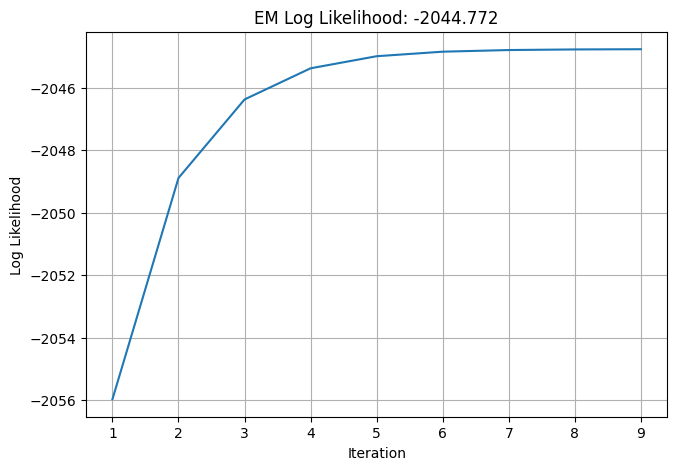

In [3]:
# reorder best fit theta
best_fit = [order_theta(best_fit[0]), best_fit[1], best_fit[2]]

# check results from best fit
em_results = pd.DataFrame({"theta_hat": order_theta(best_fit[0]), "theta": theta},
                          index=["w", "mu_1", "mu_2", "sigma_1", "sigma_2"])

# compute absolute error
em_results['Abs. Error'] = np.abs(em_results['theta_hat'] - em_results['theta'])

# absolute percentage error
em_results["APE"] = 100*em_results['Abs. Error']/em_results['theta']
em_results["APE"] = em_results["APE"].round(2).astype(str) + "%"

# display
display(em_results)

# plot LL
plt.figure(figsize=(7.5,5))
plt.plot(np.cumsum(np.ones(best_fit[2])), best_fit[1])
plt.xlabel("Iteration")
plt.ylabel("Log Likelihood")

# include LL at termination in plot title
plt.title(f"EM Log Likelihood: {np.round(best_fit[1][-1],4)}")
plt.grid()
plt.show()


Estimates

$$
\hat{w}, \hat{\mu}_{1}, \hat{\mu}_{2}, \hat{\sigma}_{1}, \hat{\sigma}_{2} = 0.335746,0.980931,3.027215,0.963352,1.927021
$$

are close to simulation parameters:

$$
w, \mu_{1}, \mu_{2}, \sigma_{1}, \sigma_{2} = 0.333,1.0,3.0,1.0,2.0
$$